In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [ ]:

data = load_breast_cancer()

X = data.data
y = data.target

print(data.target_names)
print(len(X), "samples")

['malignant' 'benign']
569 samples


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

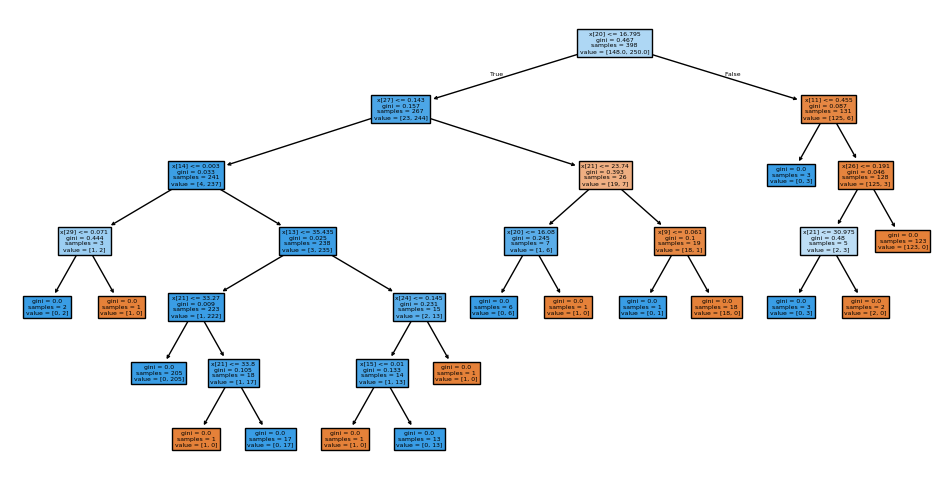

In [ ]:

plt.figure(figsize=(12,6))
plot_tree(dt, filled=True)
plt.show()

In [ ]:

train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9181286549707602
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        64
           1       0.93      0.93      0.93       107

    accuracy                           0.92       171
   macro avg       0.91      0.91      0.91       171
weighted avg       0.92      0.92      0.92       171



In [ ]:

path = dt.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas

scores = []

for a in alphas:
    model = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

best_alpha = alphas[np.argmax(scores)]
print("Best alpha:", best_alpha)

pruned_dt = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
pruned_dt.fit(X_train, y_train)

print("Pruned Test Accuracy:", pruned_dt.score(X_test, y_test))

Best alpha: 0.0029528585562200657
Pruned Test Accuracy: 0.935672514619883


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

print("RF Train:", rf.score(X_train, y_train))
print("RF Test :", rf.score(X_test, y_test))

RF Train: 1.0
RF Test : 0.9415204678362573


In [ ]:

stump = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(
    estimator=stump,
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train, y_train)

print("AdaBoost Train:", ada.score(X_train, y_train))
print("AdaBoost Test :", ada.score(X_test, y_test))

AdaBoost Train: 1.0
AdaBoost Test : 0.9532163742690059


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(dt, X, y, cv=5)
print(scores.mean())

0.9173420276354604
